# Chapter 13: Matrix Encoding
---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [ ]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import math
import itertools
from scipy.sparse import diags
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit.circuit.library import QFT, phase_estimation, HamiltonianGate
from qiskit.quantum_info import SparsePauliOp
from Chapter03_EngineeringOptimization_functions import PlaneStressCantilever
from qiskit.circuit.library import  StatePreparation,DiagonalGate, ZGate, XGate, RYGate, UCGate
from Chapter03_EngineeringOptimization_functions import (truss2x2,truss3x2,truss2x3,truss3x3,truss_10bar,
                                                         PlaneStressCantilever)
from Chapter08_QuantumGates_functions import  (simulate_statevector,  simulate_measurements, 
                                              estimateCircuitGates, findActualHardwareRequirements)
from Chapter13_MatrixEncoding_functions import (LCU_Ax,Pauli_Block_Encoding)

BASIS = ['cx', 'u', 'x', 'h', 'ry', 'rz', 'rx', 'p']   # transpilation basis

## LCU Example 1
### Step 1: Prepare state and coefficients

Classical y: [2 1]
Resulting Statevector:


<IPython.core.display.Latex object>

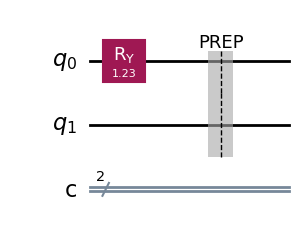

In [39]:
# A = [2 1; 1 2]
# A_tilde = A/3 = 2/3*I + 1/3*X
# x = [1,0]

A = np.array([[2, 1], [1, 2]])

A_scaling = 3
x= np.array([1,0])
y_classical = A @ x
print("Classical y:", y_classical)
qc = QuantumCircuit(2, 2)
c = np.array([2/3, 1/3])
theta = 2 * np.arctan(np.sqrt(c[1]/c[0]))
qc.ry(theta, 0)  
qc.barrier(label = "PREP")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 2: Apply controlled operations

Resulting Statevector:


<IPython.core.display.Latex object>

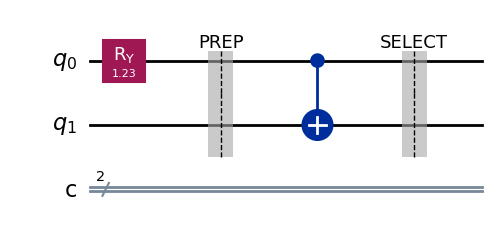

In [40]:
# No gate needed for I
qc.cx(control_qubit=0, target_qubit=1, ctrl_state='1')
qc.barrier(label = "SELECT")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 3: Ancilla clean up 

Resulting Statevector:


<IPython.core.display.Latex object>

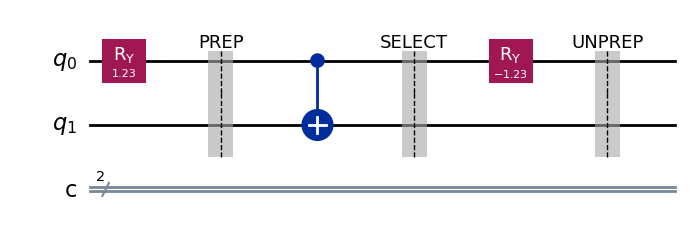

In [41]:
qc.ry(-theta, 0)
qc.barrier(label = "UNPREP")
state = Statevector.from_instruction(qc)
print("Resulting Statevector:")
display(state.draw('latex'))
display(qc.draw('mpl'))

### Step 4: measurement

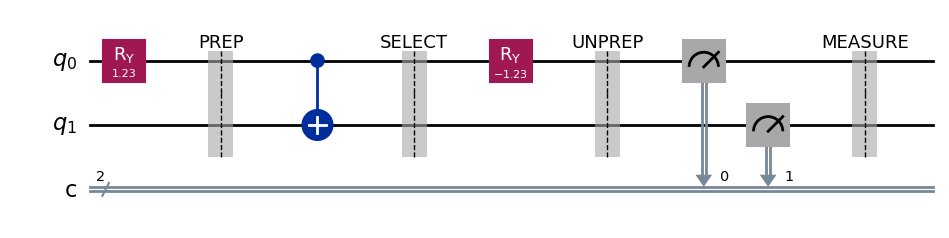

{'00': 4389, '10': 1090}


In [42]:
qc.measure(0, 0)   # measure ancilla q0 -> classical bit 0
qc.measure(1, 1)   # measure system  q1 -> classical bit 1
qc.barrier(label = "MEASURE")
display(qc.draw('mpl'))
counts = simulate_measurements(qc, shots=10000)

# Post-select: keep only shots where ancilla (bit 0) = 0
accepted = {k: v for k, v in counts.items() if k[-1] == '0'}
print(accepted)
total_accepted = sum(accepted.values())
# typical {'00': 4451, '10': 1115}



### Step 5: Scaling, etc

In [48]:
PSuccess = total_accepted / 10000
print("Post-selection success probability:", PSuccess)
P00 = accepted.get('00', 0) / total_accepted
P10 = accepted.get('10', 0) / total_accepted
y_quantum = np.sqrt(PSuccess) * np.array([np.sqrt(P00), np.sqrt(P10)])
print("Quantum y (post-selected):", y_quantum)
print("Quantum y (scaled):", y_quantum * A_scaling)

Post-selection success probability: 0.5479
Quantum y (post-selected): [0.66249528 0.33015148]
Quantum y (scaled): [1.98748585 0.99045444]


## A*x Example 2

A =
[[ 2.  1.]
 [ 1. -2.]]
x = [1.+0.j 0.+0.j]
Expected Ax = [2.+0.j 1.+0.j]

theta = 1.230959 rad  (70.5288 deg)

Full statevector: [ 0.6667+0.j -0.4714+0.j  0.3333+0.j  0.4714+0.j]

LCU result:    [2. 1.]
Classical Ax:  [2. 1.]
Match:         True

Success probability: 0.5556  (= ||Ax||^2 / alpha^2 = 5.0000 / 9.0000)



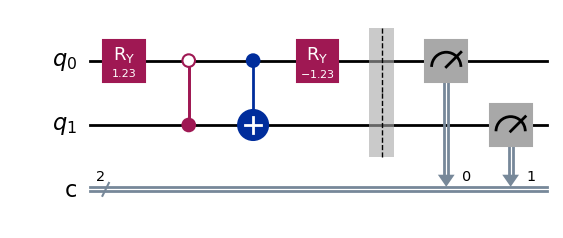

In [22]:
# -------------------------------------------------------
# LCU Example 2: A = 2Z + X, x = |0>, alpha = 3
# -------------------------------------------------------

# 1. Define A and x
c0, c1 = 2.0, 1.0
alpha   = c0 + c1            # = 3

Z = np.array([[1,  0], [0, -1]], dtype=float)
X = np.array([[0,  1], [1,  0]], dtype=float)
A = c0 * Z + c1 * X

x        = np.array([1, 0], dtype=complex)   # |0>
expected = A @ x
print("A =");           print(A)
print("x =",           x)
print("Expected Ax =", expected)
print()

# 2. PREP angle
# Ancilla amplitudes: (sqrt(|c0|/alpha), sqrt(|c1|/alpha))
# => theta = 2 * arctan(sqrt(|c1| / |c0|))
theta = 2 * np.arctan(np.sqrt(np.abs(c1) / np.abs(c0)))
print(f"theta = {theta:.6f} rad  ({np.degrees(theta):.4f} deg)")
print()

# 3. Build circuit
# q0 = ancilla, q1 = system
qc = QuantumCircuit(2, 2)

# PREP: encode (sqrt(2/3), sqrt(1/3)) on ancilla
qc.ry(theta, 0)

# System qubit: x = |0>, no gate needed

# SELECT: controlled unitaries
# Term 0: Z on system when ancilla = |0>
qc.cz(control_qubit=0, target_qubit=1, ctrl_state='0')

# Term 1: X on system when ancilla = |1>
qc.cx(control_qubit=0, target_qubit=1, ctrl_state='1')

# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 4. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector:", np.round(state.data, 4))
print()
qc.barrier()
qc.measure(0, 0)   # measure ancilla q0 -> classical bit 0
qc.measure(1, 1)   # measure system  q1 -> classical bit 1
# 5. Post-select on ancilla q0 = 0 (even indices: 0, 2)
# and rescale by alpha
result = state.data[[0, 2]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 6. Success probability
prob = np.linalg.norm(state.data[[0, 2]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 7. Draw circuit
print()
qc.draw('mpl')

## Example 3

A =
[[ 2. -1.]
 [-1. -2.]]
x = [0.7071+0.j 0.7071+0.j]
Expected Ax = [ 0.7071+0.j -2.1213+0.j]
         = (1/sqrt(2)) * [ 1.+0.j -3.+0.j]

theta = 1.230959 rad  (70.5288 deg)
  (same as Example 2: |c0|=2, |c1|=1 unchanged)

phase(c0) = 0.0000  -> no global phase on Z gate
phase(c1) = 3.1416  -> global_phase = pi on X gate

Full statevector: [ 0.2357+0.j -0.6667+0.j -0.7071+0.j  0.    +0.j]

LCU result:    [ 0.7071 -2.1213]
Classical Ax:  [ 0.7071 -2.1213]
Match:         True

Success probability: 0.5556  (= ||Ax||^2 / alpha^2 = 5.0000 / 9.0000)



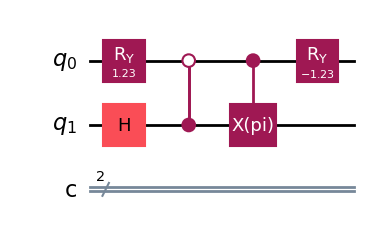

In [16]:
# -------------------------------------------------------
# LCU Example 3: A = 2Z - X, x = |+>, alpha = 3
# -------------------------------------------------------

# 1. Define A and x
c0, c1 = 2.0, -1.0
alpha   = np.abs(c0) + np.abs(c1)   # = 3

Z = np.array([[1,  0], [0, -1]], dtype=float)
X = np.array([[0,  1], [1,  0]], dtype=float)
A = c0 * Z + c1 * X

x        = np.array([1, 1], dtype=complex) / np.sqrt(2)   # |+>
expected = A @ x
print("A =");           print(A)
print("x =",           np.round(x, 4))
print("Expected Ax =", np.round(expected, 4))
print(f"         = (1/sqrt(2)) * {np.round(expected * np.sqrt(2), 4)}")
print()

# 2. PREP angle
# Uses |c0|, |c1| -- sign is handled separately via global_phase
theta = 2 * np.arctan(np.sqrt(np.abs(c1) / np.abs(c0)))
print(f"theta = {theta:.6f} rad  ({np.degrees(theta):.4f} deg)")
print(f"  (same as Example 2: |c0|=2, |c1|=1 unchanged)")
print()

# 3. Phase of each coefficient
phase0 = np.angle(c0)   # 0   (c0 > 0)
phase1 = np.angle(c1)   # pi  (c1 < 0)
print(f"phase(c0) = {phase0:.4f}  -> no global phase on Z gate")
print(f"phase(c1) = {phase1:.4f}  -> global_phase = pi on X gate")
print()

# 4. Build circuit
# q0 = ancilla, q1 = system
qc = QuantumCircuit(2, 2)

# PREP: same angle as Example 2 since |c0|, |c1| unchanged
qc.ry(theta, 0)

# System qubit: x = |+>
qc.h(1)

# SELECT: controlled unitaries
# Term 0: Z on system when ancilla = |0>, no phase (c0 > 0)
qc.cz(control_qubit=0, target_qubit=1, ctrl_state='0')

# Term 1: X on system when ancilla = |1>, global_phase = pi (c1 < 0)
gate_x = QuantumCircuit(1, global_phase=phase1)
gate_x.x(0)
ctrl_x = gate_x.to_gate(label='X(pi)').control(1, ctrl_state='1')
qc.append(ctrl_x, [0, 1])

# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 5. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector:", np.round(state.data, 4))
print()

# 6. Post-select on ancilla q0 = 0 (even indices: 0, 2)
# and rescale by alpha
result = state.data[[0, 2]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 7. Success probability
prob = np.linalg.norm(state.data[[0, 2]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 8. Draw circuit
print()
qc.draw('mpl')

## Example 4

A =
[[ 0.75  0.25  0.    0.  ]
 [ 0.25  0.75  0.    0.  ]
 [ 0.    0.   -0.75  0.25]
 [ 0.    0.    0.25 -0.75]]
x = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
Expected Ax = [0.75+0.j 0.25+0.j 0.  +0.j 0.  +0.j]

theta = pi/3 = 1.047198, computed = 1.047198

Full statevector (8 components):
  |000> (index 0): 0.7500+0.0000j
  |100> (index 1): -0.4330+0.0000j
  |010> (index 2): 0.2500+0.0000j
  |110> (index 3): 0.4330+0.0000j

LCU result:    [0.75 0.25 0.   0.  ]
Classical Ax:  [0.75 0.25 0.   0.  ]
Match:         True

Success probability: 0.6250  (= ||Ax||^2 / alpha^2 = 0.6250 / 1.0000)



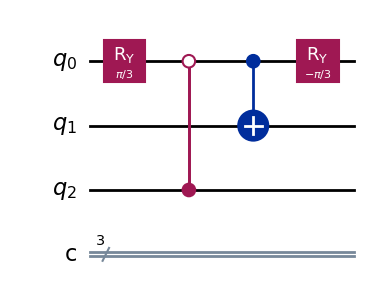

In [17]:

# -------------------------------------------------------
# LCU Example 4: A = (3/4)(Z⊗I) + (1/4)(I⊗X), x = |00>
# 3 qubits total: q0 = ancilla, q1 q2 = system
# -------------------------------------------------------

# 1. Define A and x
c0, c1 = 3/4, 1/4
alpha   = c0 + c1    # = 1

I = np.eye(2)
Z = np.array([[1,  0], [0, -1]], dtype=float)
X = np.array([[0,  1], [1,  0]], dtype=float)

ZI = np.kron(Z, I)
IX = np.kron(I, X)
A  = c0 * ZI + c1 * IX

x        = np.array([1, 0, 0, 0], dtype=complex)   # |00>
expected = A @ x
print("A ="); print(A)
print("x =", x)
print("Expected Ax =", np.round(expected, 4))
print()

# 2. PREP angle
# Same coefficients as Example 1: theta = pi/3
theta = 2 * np.arctan(np.sqrt(c1 / c0))
print(f"theta = pi/3 = {np.pi/3:.6f}, computed = {theta:.6f}")
print()

# 3. Build circuit
# q0 = ancilla, q1 = system LSB, q2 = system MSB
# Qiskit ordering: QuantumCircuit(q0, q1, q2)
qc = QuantumCircuit(3, 3)

# PREP: encode (sqrt(3)/2, 1/2) on ancilla q0
qc.ry(theta, 0)

# System qubits q1, q2: x = |00>, no gates needed

# SELECT: controlled unitaries
# Term 0: Z⊗I when ancilla = |0>
#   -> Z acts on q2 (MSB of system), identity on q1
qc.cz(control_qubit=0, target_qubit=2, ctrl_state='0')

# Term 1: I⊗X when ancilla = |1>
#   -> identity on q2, X acts on q1 (LSB of system)
qc.cx(control_qubit=0, target_qubit=1, ctrl_state='1')

# Inverse rotation on ancilla
qc.ry(-theta, 0)

# 4. Simulate statevector
state = Statevector.from_instruction(qc)
print("Full statevector (8 components):")
labels = [f"|{format(i,'03b')[::-1]}>" for i in range(8)]  # |q2 q1 q0>
for i, (label, amp) in enumerate(zip(labels, state.data)):
    if abs(amp) > 1e-10:
        print(f"  {label} (index {i}): {amp:.4f}")
print()

# 5. Post-select on ancilla q0 = 0
# In Qiskit statevector, q0 is LSB -> even indices {0,2,4,6}
result = state.data[[0, 2, 4, 6]] * alpha
print("="*40)
print("LCU result:   ", np.round(np.real_if_close(result),   4))
print("Classical Ax: ", np.round(np.real_if_close(expected), 4))
print("Match:        ", np.allclose(result, expected))
print("="*40)
print()

# 6. Success probability
prob = np.linalg.norm(state.data[[0, 2, 4, 6]])**2
print(f"Success probability: {prob:.4f}  (= ||Ax||^2 / alpha^2 = {np.linalg.norm(expected)**2:.4f} / {alpha**2:.4f})")

# 7. Draw circuit
print()
qc.draw('mpl')

## Pauli Expansion

In [18]:
A = np.array([
    [1, 0, 0, 0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.5, 0, 0, 1]
])
pauliSplit = SparsePauliOp.from_operator(A)
print(pauliSplit.paulis)
print(pauliSplit.coeffs)

['II', 'XX', 'YY']
[ 1.  +0.j  0.25+0.j -0.25+0.j]


## Performing Ax using LCU_Ax

{'alpha': np.float64(1.5), 'num_system': 2, 'num_ancilla': 2, 'coeffs': array([ 1.  +0.j,  0.25+0.j, -0.25+0.j]), 'pauli_split': SparsePauliOp(['II', 'XX', 'YY'],
              coeffs=[ 1.  +0.j,  0.25+0.j, -0.25+0.j])}
Expected output: [0.6 0.8 0.  0.3]
Quantum output: [0.6 0.8 0.  0.3]
Success probability: 0.4844


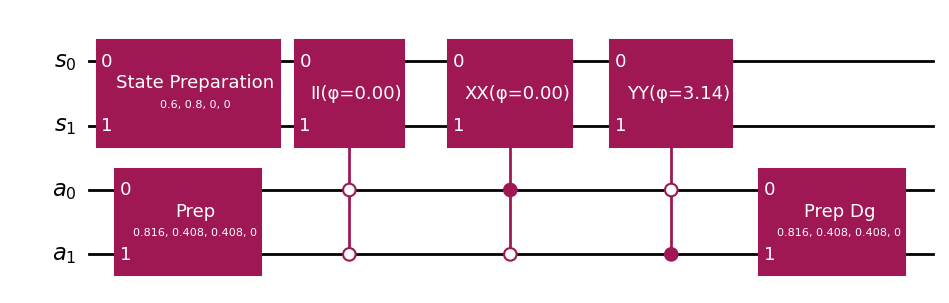

In [19]:
A = np.array([
    [1, 0, 0, 0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

expected_output = A @ x
# Create circuit
qc, metadata = LCU_Ax(A, x)
print(metadata)
# Get the exact statevector
final_state = Statevector(qc)
num_system = metadata['num_system']
alpha = metadata['alpha']

res_vector = final_state.data[:2**num_system] * alpha
success_prob = np.linalg.norm(final_state.data[:2**num_system])**2

print("Expected output:", np.round(np.real_if_close(expected_output), 4))
print("Quantum output:", np.round(np.real_if_close(res_vector), 4))
print("Success probability:", np.round(success_prob, 4))
qc.draw('mpl')

## Choose from Examples

In [20]:
example = 6
if (example == 1):
	A = np.array([[1,0],[0,1]]) 
	b = np.array([1,0])
elif (example == 2):
	A = np.array([[2,-1],[-1,2]])
	b = np.array([1,1])/np.sqrt(2)
elif (example == 3):
	A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
	b = np.array([1,0,0,0])
elif (example == 4):
	A = np.array([[1.5,0.5],[0.5,1.5]])
	b = np.array([1,0])
elif (example == 5):
	p = 1
	A = np.array([[5*(10**p),-1],[-1,5]])
	b = np.array([1,0])
elif (example == 6):
	N = 2**5
	values = [-np.ones(N-1),2*np.ones(N),-np.ones(N-1)]
	A = diags(values,[-1,0,1]).toarray()/4
	b = np.zeros(N)
	b[0] = 1

print("A shape:", A.shape)
print("b shape:", b.shape)

A shape: (32, 32)
b shape: (32,)


## Block encoding

In [21]:
U_matrix, metadata = Pauli_Block_Encoding(A, mode='statevector')
alpha = metadata['alpha']
print("U shape:", U_matrix.shape)
print("alpha:", alpha)

KeyboardInterrupt: 

## LCU encoding of truss stiffness matrices

In [ ]:
fem_model= truss3x3()
fem_model.plot_truss()
K_full = fem_model.assemble_stiffness()
print("Size of K_full:", K_full.shape)
all_dofs = set(range(fem_model.n_dofs))
free_dofs = list(all_dofs - set(fem_model.fixed_dofs))
K = K_full[np.ix_(free_dofs, free_dofs)]
f = fem_model.loads[free_dofs]
print("Size of K:", K.shape)
N = 8
A = K[:N, :N]  # Just take a 4x4 block for testing
print("Size of sub-matrix A:", A.shape)
pauliSplit = SparsePauliOp.from_operator(A)
print("Number of Pauli terms:",pauliSplit.coeffs.shape[0])

# Resource requirements
num_ancilla = int(np.ceil(np.log2(pauliSplit.coeffs.shape[0])))  # One ancilla per Pauli term
num_system = int(np.ceil(np.log2(N)))
print(f"Ancilla qubits needed: {num_ancilla}")
print(f"System qubits needed: {num_system}")
print(f"Total qubits: {num_ancilla + num_system}")

# Normalization constant
alpha = np.sum(np.abs(pauliSplit.coeffs))
print(f"Normalization α: {alpha:.4e}")

## FEM Matrix Circuit analysis

In [ ]:
# Create a simple test vector
x = np.zeros(8)
x[0] = 1.0  # Unit displacement at first DOF

# Create LCU circuit
qc, metadata = LCU_Ax(A, x, mode='statevector')

# Analyze circuit
print(f"Circuit depth: {qc.depth()}")
print(f"Number of qubits: {qc.num_qubits}")

# Decompose to basis gates
qc_decomposed = qc.decompose(reps=3)
print(f"\nAfter decomposition to basis gates:")
print(f"Circuit depth: {qc_decomposed.depth()}")
print(f"Total gates: {sum(qc_decomposed.count_ops().values())}")